**Goal:**

Build a model that predicts the emi eligibility of every individual customer ***(classification)*** with more than 90% accuracy.

**Provision:**

We are provided with an EMI prediction dataset containing data on personal demographics, employment and income, housing and family, monthly financial obligations, and financial status and credit history.

## Data acquisition and understanding

In [390]:
import pandas as pd
df = pd.read_csv(r'C:\Users\nived\Desktop\guvi\EMI Prediction\EMI Prediction\emi_prediction_dataset.csv')
df.head()

C:\Users\nived\AppData\Local\Temp\ipykernel_2652\1594610132.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\nived\Desktop\guvi\EMI Prediction\EMI Prediction\emi_prediction_dataset.csv')


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [391]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [392]:
df.shape

(404800, 27)

In [393]:
df['age']

# A numerical column denoting the age of the customer
# It spans from 26 to 58

0         38.0
1         38.0
2         38.0
3         58.0
4         48.0
          ... 
404795    27.0
404796    38.0
404797    32.0
404798    48.0
404799    38.0
Name: age, Length: 404800, dtype: object

In [394]:
# gender - Male, Female
# marital status - Unmarried, Married

In [395]:
df['education'].unique()

array(['Professional', 'Graduate', 'High School', 'Post Graduate', nan],
      dtype=object)

In [396]:
# monthly salary - numeric data containing the monthly salary

In [397]:
df['employment_type'].unique()

# It denotes the different sectors of employment

array(['Private', 'Government', 'Self-employed'], dtype=object)

In [398]:
df['company_type'].unique()

array(['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small'],
      dtype=object)

In [399]:
df['house_type'].unique()

array(['Rented', 'Family', 'Own'], dtype=object)

In [400]:
df.monthly_rent

0         20000.0
1             0.0
2             0.0
3             0.0
4             0.0
           ...   
404795    10400.0
404796        0.0
404797     6300.0
404798        0.0
404799        0.0
Name: monthly_rent, Length: 404800, dtype: float64

In [401]:
df.family_size.unique()

array([3, 2, 4, 5, 1])

In [402]:
df.dependents.unique()

array([2, 1, 3, 4, 0])

In [403]:
df.school_fees

0             0.0
1          5100.0
2             0.0
3         11400.0
4          9400.0
           ...   
404795     2800.0
404796    14000.0
404797        0.0
404798        0.0
404799        0.0
Name: school_fees, Length: 404800, dtype: float64

In [404]:
df.college_fees

0             0.0
1             0.0
2             0.0
3             0.0
4         21300.0
           ...   
404795     7000.0
404796        0.0
404797        0.0
404798        0.0
404799        0.0
Name: college_fees, Length: 404800, dtype: float64

In [405]:
df.travel_expenses

0          7200.0
1          1400.0
2         10200.0
3          6200.0
4          3600.0
           ...   
404795     2200.0
404796     2600.0
404797     2000.0
404798     7000.0
404799     4800.0
Name: travel_expenses, Length: 404800, dtype: float64

In [406]:
df.groceries_utilities

0         19500.0
1          5400.0
2         19400.0
3         11900.0
4         16200.0
           ...   
404795     4900.0
404796    13600.0
404797     4600.0
404798     8900.0
404799     8100.0
Name: groceries_utilities, Length: 404800, dtype: float64

In [407]:
df.other_monthly_expenses

0         13200.0
1          3500.0
2          6000.0
3          7900.0
4          8100.0
           ...   
404795     6100.0
404796     8600.0
404797     2500.0
404798     7200.0
404799     2100.0
Name: other_monthly_expenses, Length: 404800, dtype: float64

In [408]:
df.existing_loans.unique()

array(['Yes', 'No'], dtype=object)

In [409]:
df.current_emi_amount

0         23700.0
1          4100.0
2             0.0
3             0.0
4             0.0
           ...   
404795        0.0
404796        0.0
404797        0.0
404798        0.0
404799        0.0
Name: current_emi_amount, Length: 404800, dtype: float64

In [410]:
df.credit_score

0         660.0
1         714.0
2         650.0
3         685.0
4         770.0
          ...  
404795    649.0
404796    712.0
404797    676.0
404798    784.0
404799    641.0
Name: credit_score, Length: 404800, dtype: float64

In [411]:
df.emergency_fund

0          70200.0
1          26900.0
2         324200.0
3         178100.0
4          28200.0
            ...   
404795     32600.0
404796     38100.0
404797     39700.0
404798     45600.0
404799     99400.0
Name: emergency_fund, Length: 404800, dtype: float64

In [412]:
df.emi_scenario.unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [413]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

**General understanding:**

* Total number of columns = 26

* Target column (regression) = max_monthly_emi
* Target column (classification) = emi_eligibility

* ***Numerical columns:*** age, monthly_salary, years_of_employment, monthly_rent, family_size, dependents, school_fees, college_fees, travel_expenses, groceries_utilities, other_monthly_expenses, current_emi_amount, credit_score, bank_balance, emergency_fund, requested_amount, requested_tenure

* Total numerical columns = 17

* ***Categorical columns:*** gender, marital_status, education, employment_type, company_type, house_type, existing_loans, emi_scenario

* Total categorical columns = 7

**Hypothesis:**

* Higher the years of employment, maximum the emi amount.
* Lower the family size and number of dependents, higher the emi amount.
* Customers with a negative bank balance are ineligible for emi.
* Customer with existing loans are ineligible for emi.
* Monthly salary should be greater than the total monthly financial obligations to be eligible for emi.

## Data cleaning

In [414]:
df['age'].value_counts()

age
38.0      91577
32.0      75958
48.0      60748
27.0      45461
58.0      30326
38        28773
32        24351
48        19540
27        14327
58        10033
39.0        368
37.0        365
33.0        326
31.0        285
49.0        258
47.0        226
28.0        181
26.0        159
38.0        158
59.0        134
57.0        124
37          122
33          119
32.0        115
39          111
31          108
48.0        100
47           71
27.0         64
49           62
26           50
58.0         49
59           49
28           49
57           44
37.0          3
26.0          2
39.0          1
58.0.0        1
38.0.0        1
32.0.0        1
Name: count, dtype: int64

In [415]:
df['age'].describe()

count     404800.0
unique        41.0
top           38.0
freq       91577.0
Name: age, dtype: float64

In [416]:
df['age'].dtype # datatype as object detected

dtype('O')

In [417]:
df['age'] = df['age'].replace(['58.0.0', '38.0.0', '32.0.0'], [58.0, 38.0, 32.0]) # Unrealistic values found and replaced

In [418]:
df['age'] = df['age'].astype(float) # Datatype changed to float

In [419]:
df['age'].describe()

count    404800.000000
mean         38.875860
std           9.303593
min          26.000000
25%          32.000000
50%          38.000000
75%          48.000000
max          59.000000
Name: age, dtype: float64

In [420]:
df['age'].isna().sum()

np.int64(0)

In [421]:
df['gender'].value_counts()

gender
Male      237427
Female    158351
MALE        1865
M           1843
male        1815
F           1171
female      1165
FEMALE      1163
Name: count, dtype: int64

In [422]:
df['gender'] = df['gender'].replace(['MALE', 'M', 'male'], 'Male')
df['gender'] = df['gender'].replace(['FEMALE', 'F', 'female'], 'Female')

In [423]:
df['gender'].value_counts()

gender
Male      242950
Female    161850
Name: count, dtype: int64

In [424]:
df['gender'].isna().sum()

np.int64(0)

In [425]:
df['marital_status'].value_counts()

marital_status
Married    307837
Single      96963
Name: count, dtype: int64

In [426]:
df['marital_status'].isna().sum()

np.int64(0)

In [427]:
df['education'].value_counts()

education
Graduate         181015
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

In [428]:
df['education'].isna().sum()

np.int64(2404)

In [429]:
df = df.dropna(subset = 'education')

In [430]:
df['education'].isna().sum()

np.int64(0)

In [431]:
df['monthly_salary'] = df['monthly_salary'].str.replace('.0.0', '')

In [432]:
df['monthly_salary'] = df['monthly_salary'].astype(float)

In [433]:
df['monthly_salary'].describe()

count    402396.000000
mean      59497.766156
std       43346.681180
min        3967.000000
25%       35400.000000
50%       51600.000000
75%       73000.000000
max      499970.000000
Name: monthly_salary, dtype: float64

In [434]:
df.monthly_salary.isna().sum()

np.int64(0)

In [435]:
df['employment_type'].value_counts()

employment_type
Private          281432
Government        80663
Self-employed     40301
Name: count, dtype: int64

In [436]:
df['employment_type'].isna().sum()

np.int64(0)

In [437]:
df['years_of_employment'].dtype

dtype('float64')

In [438]:
df['years_of_employment'].value_counts()

years_of_employment
0.5     51141
0.7      8021
0.6      8008
0.8      7719
0.9      7495
        ...  
34.5       13
35.8       12
35.6       11
34.8       11
35.1       11
Name: count, Length: 356, dtype: int64

In [439]:
df['years_of_employment'].isna().sum()

np.int64(0)

In [440]:
df.company_type.unique()

array(['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small'],
      dtype=object)

In [441]:
df.company_type.isna().sum()

np.int64(0)

In [442]:
df.house_type.unique()

array(['Rented', 'Family', 'Own'], dtype=object)

In [443]:
df.monthly_rent.dtype

dtype('float64')

In [444]:
df.monthly_rent.isna().sum()

np.int64(2417)

In [445]:
df.monthly_rent.describe()

count    399979.000000
mean       5827.676443
std        8647.754624
min           0.000000
25%           0.000000
50%           0.000000
75%       10600.000000
max       80000.000000
Name: monthly_rent, dtype: float64

In [446]:
df.family_size.unique()

array([3, 2, 4, 5, 1])

In [447]:
df.family_size.dtype

dtype('int64')

In [448]:
df.dependents.unique()

array([2, 1, 3, 4, 0])

In [449]:
df.dependents.dtype

dtype('int64')

In [450]:
df.school_fees.dtype

dtype('float64')

In [451]:
df.school_fees.isna().sum()

np.int64(0)

In [452]:
df.school_fees.describe()

count    402396.000000
mean       4624.038261
std        5061.068383
min           0.000000
25%           0.000000
50%        3000.000000
75%        9000.000000
max       15000.000000
Name: school_fees, dtype: float64

In [453]:
df.college_fees.describe()

count    402396.000000
mean       4065.032207
std        7318.303348
min           0.000000
25%           0.000000
50%           0.000000
75%        6500.000000
max       25000.000000
Name: college_fees, dtype: float64

In [454]:
df.college_fees.isna().sum()

np.int64(0)

In [455]:
df.travel_expenses.describe()

count    402396.000000
mean       5687.640036
std        3393.148581
min         600.000000
25%        3200.000000
50%        4900.000000
75%        7400.000000
max       30300.000000
Name: travel_expenses, dtype: float64

In [456]:
df.travel_expenses.isna().sum()

np.int64(0)

In [457]:
df.groceries_utilities.describe()

count    402396.000000
mean      12805.637233
std        6995.414202
min        1800.000000
25%        7700.000000
50%       11400.000000
75%       16400.000000
max       71200.000000
Name: groceries_utilities, dtype: float64

In [458]:
df.groceries_utilities.isna().sum()

np.int64(0)

In [459]:
df.other_monthly_expenses.describe()

count    402396.000000
mean       7120.051144
std        4511.716420
min         600.000000
25%        3800.000000
50%        6000.000000
75%        9300.000000
max       42900.000000
Name: other_monthly_expenses, dtype: float64

In [460]:
df.other_monthly_expenses.isna().sum()

np.int64(0)

In [461]:
df.credit_score.describe()

count    399991.000000
mean        700.852217
std          88.456413
min           0.000000
25%         654.000000
50%         701.000000
75%         748.000000
max        1200.000000
Name: credit_score, dtype: float64

In [462]:
df[df.credit_score > 900]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
166,38.0,Female,Married,Post Graduate,95900.0,Private,3.3,MNC,Family,0.0,...,No,0.0,1200.0,695300.0,383000.0,Vehicle EMI,482000.0,19,Not_Eligible,23760.0
290,32.0,Male,Single,Professional,143300.0,Private,0.5,Startup,Rented,35800.0,...,Yes,21200.0,999.0,722800.0,225400.0,Home Appliances EMI,22000.0,25,Eligible,10113.6
763,38.0,Male,Married,Graduate,43400.0,Private,0.6,Startup,Rented,15100.0,...,Yes,11600.0,1200.0,320100.0,99500.0,Personal Loan EMI,652000.0,58,Not_Eligible,500.0
846,27.0,Male,Single,Graduate,30900.0,Government,0.5,Small,Family,0.0,...,Yes,6400.0,999.0,145500.0,60300.0,Home Appliances EMI,50000.0,33,Eligible,3052.0
852,27.0,Male,Married,Graduate,41600.0,Private,1.3,MNC,Rented,8100.0,...,Yes,9800.0,1200.0,35500.0,8800.0,Home Appliances EMI,99000.0,17,Not_Eligible,828.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404442,27.0,Male,Single,Graduate,49800.0,Self-employed,2.6,Startup,Own,0.0,...,No,0.0,1200.0,391700.0,148600.0,E-commerce Shopping EMI,141000.0,3,Not_Eligible,12276.0
404445,38.0,Male,Married,Graduate,41700.0,Government,16.0,MNC,Rented,12700.0,...,Yes,11200.0,999.0,32600.0,7700.0,E-commerce Shopping EMI,63000.0,11,Not_Eligible,500.0
404627,58.0,Female,Married,High School,41400.0,Private,1.1,Mid-size,Family,0.0,...,No,0.0,1200.0,268200.0,119400.0,E-commerce Shopping EMI,188000.0,13,Not_Eligible,11880.0
404690,58.0,Female,Married,Graduate,77400.0,Self-employed,3.6,Mid-size,Rented,17700.0,...,Yes,22700.0,999.0,321400.0,82800.0,Personal Loan EMI,262000.0,29,Not_Eligible,500.0


In [463]:
df.credit_score = df.credit_score.clip(upper = 900)

In [464]:
df.credit_score.isna().sum()

np.int64(2405)

In [465]:
df = df.dropna(subset = 'credit_score')

In [466]:
df.bank_balance.dtype

dtype('O')

In [467]:
df['bank_balance'] = (df['bank_balance'].astype(str).str.replace(r'(\.0)+$', '.0', regex=True))

In [468]:
df.bank_balance.isna().sum()

np.int64(0)

In [469]:
df[df.bank_balance == 'nan.0']

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
15035,58.0,Male,Married,Graduate,41500.0,Government,5.6,MNC,Family,0.0,...,No,0.0,761.0,nan.0,126900.0,Vehicle EMI,993000.0,42,Not_Eligible,9801.0
21911,58.0,Male,Married,Professional,77800.0,Private,0.5,MNC,Rented,15600.0,...,No,0.0,697.0,nan.0,68400.0,Home Appliances EMI,112000.0,28,Not_Eligible,4128.0
119042,38.0,Male,Married,Professional,131000.0,Private,1.8,Startup,Own,0.0,...,Yes,26200.0,656.0,nan.0,289700.0,Personal Loan EMI,544000.0,57,High_Risk,15015.0
176100,38.0,Female,Married,Graduate,79500.0,Private,1.9,Large Indian,Family,0.0,...,No,0.0,621.0,nan.0,192000.0,Education EMI,455000.0,36,High_Risk,16000.0
185892,38.0,Male,Married,Post Graduate,53400.0,Private,0.5,Startup,Own,0.0,...,Yes,7100.0,719.0,nan.0,NaN,Personal Loan EMI,991000.0,34,Not_Eligible,6244.0
207591,38.0,Male,Married,High School,26200.0,Self-employed,0.5,Large Indian,Own,0.0,...,Yes,4400.0,699.0,nan.0,19000.0,Vehicle EMI,1471000.0,33,Not_Eligible,500.0
216848,32.0,Male,Single,Professional,118300.0,Private,5.4,Large Indian,Own,0.0,...,No,0.0,772.0,nan.0,185700.0,Home Appliances EMI,198000.0,11,Eligible,43800.0
221814,58.0,Female,Married,High School,42600.0,Private,2.6,Startup,Family,0.0,...,No,0.0,618.0,nan.0,52200.0,E-commerce Shopping EMI,69000.0,22,Not_Eligible,3360.0
226236,48.0,Female,Married,Graduate,35500.0,Private,2.3,MNC,Own,0.0,...,No,0.0,632.0,nan.0,45000.0,Education EMI,155000.0,36,Not_Eligible,4920.0
316975,38.0,Male,Married,Professional,53400.0,Government,1.6,MNC,Own,0.0,...,No,0.0,701.0,nan.0,76600.0,E-commerce Shopping EMI,151000.0,23,Eligible,16350.0


In [470]:
import numpy as np

df['bank_balance'] = df['bank_balance'].replace('nan.0', np.nan)
df['bank_balance'] = df['bank_balance'].astype(float)

In [471]:
df.bank_balance.isna().sum()

np.int64(2411)

In [472]:
df.bank_balance.isna().sum()

np.int64(2411)

In [473]:
df.bank_balance.describe()

count    3.975800e+05
mean     2.417296e+05
std      1.832813e+05
min      6.100000e+03
25%      1.044000e+05
50%      1.960000e+05
75%      3.313000e+05
max      1.717300e+06
Name: bank_balance, dtype: float64

In [474]:
df.emergency_fund.dtype

dtype('float64')

In [475]:
df.emergency_fund.isna().sum()

np.int64(2317)

In [476]:
df = df.dropna(subset = 'emergency_fund')

In [477]:
df.emergency_fund.describe()

count    397674.000000
mean      96787.740964
std       81402.149330
min        1400.000000
25%       38400.000000
50%       74100.000000
75%      130600.000000
max      891500.000000
Name: emergency_fund, dtype: float64

In [478]:
df.emi_scenario.unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [479]:
df.requested_amount.dtype

dtype('float64')

In [480]:
df.requested_amount.isna().sum()

np.int64(0)

In [481]:
df.requested_amount.describe()

count    3.976740e+05
mean     3.709295e+05
std      3.452167e+05
min      1.000000e+04
25%      1.240000e+05
50%      2.370000e+05
75%      4.940000e+05
max      1.500000e+06
Name: requested_amount, dtype: float64

In [482]:
df.requested_tenure.dtype

dtype('int64')

In [483]:
df.requested_tenure.isna().sum()

np.int64(0)

In [484]:
df.requested_tenure.describe()

count    397674.000000
mean         29.126166
std          18.098711
min           3.000000
25%          15.000000
50%          25.000000
75%          40.000000
max          84.000000
Name: requested_tenure, dtype: float64

In [485]:
df.emi_eligibility.unique()

array(['Not_Eligible', 'Eligible', 'High_Risk'], dtype=object)

In [486]:
df.emi_eligibility.isna().sum()

np.int64(0)

In [487]:
df.max_monthly_emi.dtype

dtype('float64')

In [488]:
df.max_monthly_emi.isna().sum()

np.int64(0)

In [489]:
df.max_monthly_emi.describe()

count    397674.000000
mean       6766.482575
std        7745.010379
min         500.000000
25%         500.000000
50%        4219.600000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

In [490]:
df = df.dropna(subset=['bank_balance', 'monthly_rent', 'emergency_fund'])

In [491]:
q1 = df.age.quantile(0.25)
q3 = df.age.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [492]:
(df.age > upper_bound).sum()

np.int64(0)

In [493]:
(df.age < lower_bound).sum()

np.int64(0)

In [494]:
q1 = df.monthly_salary.quantile(0.25)
q3 = df.monthly_salary.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [495]:
(df.monthly_salary > upper_bound).sum()

np.int64(11741)

In [496]:
(df.monthly_salary < lower_bound).sum()

np.int64(0)

In [497]:
df.monthly_salary = df.monthly_salary.clip(upper = upper_bound)

In [498]:
q1 = df.monthly_rent.quantile(0.25)
q3 = df.monthly_rent.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [499]:
(df.monthly_rent > upper_bound).sum()

np.int64(12399)

In [500]:
(df.monthly_rent < lower_bound).sum()

np.int64(0)

In [501]:
df.monthly_rent = df.monthly_rent.clip(upper = upper_bound)

In [502]:
q1 = df.school_fees.quantile(0.25)
q3 = df.school_fees.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [503]:
(df.school_fees > upper_bound).sum()

np.int64(0)

In [504]:
(df.school_fees < lower_bound).sum()

np.int64(0)

In [505]:
q1 = df.college_fees.quantile(0.25)
q3 = df.college_fees.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [506]:
(df.college_fees > upper_bound).sum()

np.int64(46601)

In [507]:
(df.college_fees < lower_bound).sum()

np.int64(0)

In [508]:
df.college_fees.describe()

count    392908.000000
mean       4066.876979
std        7320.223322
min           0.000000
25%           0.000000
50%           0.000000
75%        6500.000000
max       25000.000000
Name: college_fees, dtype: float64

In [509]:
import numpy as np
df['college_fees_log'] = np.log1p(df['college_fees'])

In [510]:
q1 = df.college_fees_log.quantile(0.25)
q3 = df.college_fees_log.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [511]:
(df.college_fees_log > upper_bound).sum()

np.int64(0)

In [512]:
(df.college_fees_log < lower_bound).sum()

np.int64(0)

In [513]:
q1 = df.travel_expenses.quantile(0.25)
q3 = df.travel_expenses.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [514]:
(df.travel_expenses > upper_bound).sum()

np.int64(12097)

In [515]:
(df.travel_expenses < lower_bound).sum()

np.int64(0)

In [516]:
df.travel_expenses = df.travel_expenses.clip(upper = upper_bound)

In [517]:
q1 = df.groceries_utilities.quantile(0.25)
q3 = df.groceries_utilities.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [518]:
(df.groceries_utilities > upper_bound).sum()

np.int64(11427)

In [519]:
(df.groceries_utilities < lower_bound).sum()

np.int64(0)

In [520]:
df.groceries_utilities = df.groceries_utilities.clip(upper = upper_bound)

In [521]:
q1 = df.other_monthly_expenses.quantile(0.25)
q3 = df.other_monthly_expenses.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [522]:
(df.other_monthly_expenses > upper_bound).sum()

np.int64(13127)

In [523]:
(df.other_monthly_expenses < lower_bound).sum()

np.int64(0)

In [524]:
df.other_monthly_expenses = df.other_monthly_expenses.clip(upper = upper_bound)

In [525]:
q1 = df.bank_balance.quantile(0.25)
q3 = df.bank_balance.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [526]:
(df.bank_balance > upper_bound).sum()

np.int64(12697)

In [527]:
(df.bank_balance < lower_bound).sum()

np.int64(0)

In [528]:
df.bank_balance = df.bank_balance.clip(upper = upper_bound)

In [529]:
q1 = df.emergency_fund.quantile(0.25)
q3 = df.emergency_fund.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [530]:
(df.emergency_fund > upper_bound).sum()

np.int64(17126)

In [531]:
(df.emergency_fund < lower_bound).sum()

np.int64(0)

In [532]:
df.emergency_fund = df.emergency_fund.clip(upper = upper_bound)

In [533]:
q1 = df.requested_amount.quantile(0.25)
q3 = df.requested_amount.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [534]:
(df.requested_amount > upper_bound).sum()

np.int64(25004)

In [535]:
(df.requested_amount < lower_bound).sum()

np.int64(0)

In [536]:
df['requested_amount_log'] = np.log1p(df['requested_amount'])

In [537]:
q1 = df.requested_amount_log.quantile(0.25)
q3 = df.requested_amount_log.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [538]:
(df.requested_amount_log > upper_bound).sum()

np.int64(0)

In [539]:
(df.requested_amount_log < lower_bound).sum()

np.int64(2232)

In [540]:
df.requested_amount_log = df.requested_amount_log.clip(upper = upper_bound)

In [541]:
q1 = df.max_monthly_emi.quantile(0.25)
q3 = df.max_monthly_emi.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [542]:
(df.max_monthly_emi > upper_bound).sum()

np.int64(16793)

In [543]:
(df.max_monthly_emi < lower_bound).sum()

np.int64(0)

In [544]:
df.max_monthly_emi = df.max_monthly_emi.clip(upper = upper_bound)

In [545]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'college_fees_log', 'requested_amount_log'],
      dtype='object')

In [546]:
df.shape

(392908, 29)

In [547]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392908 entries, 0 to 404799
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     392908 non-null  float64
 1   gender                  392908 non-null  object 
 2   marital_status          392908 non-null  object 
 3   education               392908 non-null  object 
 4   monthly_salary          392908 non-null  float64
 5   employment_type         392908 non-null  object 
 6   years_of_employment     392908 non-null  float64
 7   company_type            392908 non-null  object 
 8   house_type              392908 non-null  object 
 9   monthly_rent            392908 non-null  float64
 10  family_size             392908 non-null  int64  
 11  dependents              392908 non-null  int64  
 12  school_fees             392908 non-null  float64
 13  college_fees            392908 non-null  float64
 14  travel_expenses         3

**Challenges faced during data cleaning:**

* Inconsistent datatype (object instead of float)
* Unrealistic values (25.0.0)
* Misspellings
* Missing values

**Techniques used to tackle missing values:**

* In the education column, I have imputed missing values as unknown.
* Since the null values were limited, 5000 approximately altogether, dropped null values from both columns bank balance and emergency funds.

**Techniques employed to tackle outliers:**

In certain numeric columns, the outliers where detected lying above the upper bound. In such cases,

* the values were capped to the upper bound values as the count constituted less than 5% of the total entry of the column.
* log transform was applied in cases where the count exceeded 5% of the total entry of the column. When the outliers persisted, the values were clipped to the upper bound.

**Points to remember:**

* Check for the credit score column as it should lie in the range 300 to 900.
* I have clipped the credit scores exceeding 900 to 900 as it is the maximum possible score.

## Feature engineering

In [548]:
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary']

In [549]:
df['expense_to_income'] = (
    df['groceries_utilities'] +
    df['travel_expenses'] +
    df['other_monthly_expenses']
) / df['monthly_salary']

In [550]:
df['total_expenses'] = (
    df['groceries_utilities'] +
    df['travel_expenses'] +
    df['school_fees'] +
    df['college_fees'] +
    df['other_monthly_expenses']
)

In [551]:
df['savings_ratio'] = df['bank_balance'] / df['monthly_salary']

In [552]:
df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * df['requested_tenure'])

In [553]:
del df['groceries_utilities']
del df['travel_expenses']
del df['other_monthly_expenses']
del df['college_fees']
del df['school_fees']
del df['college_fees_log']

## EDA

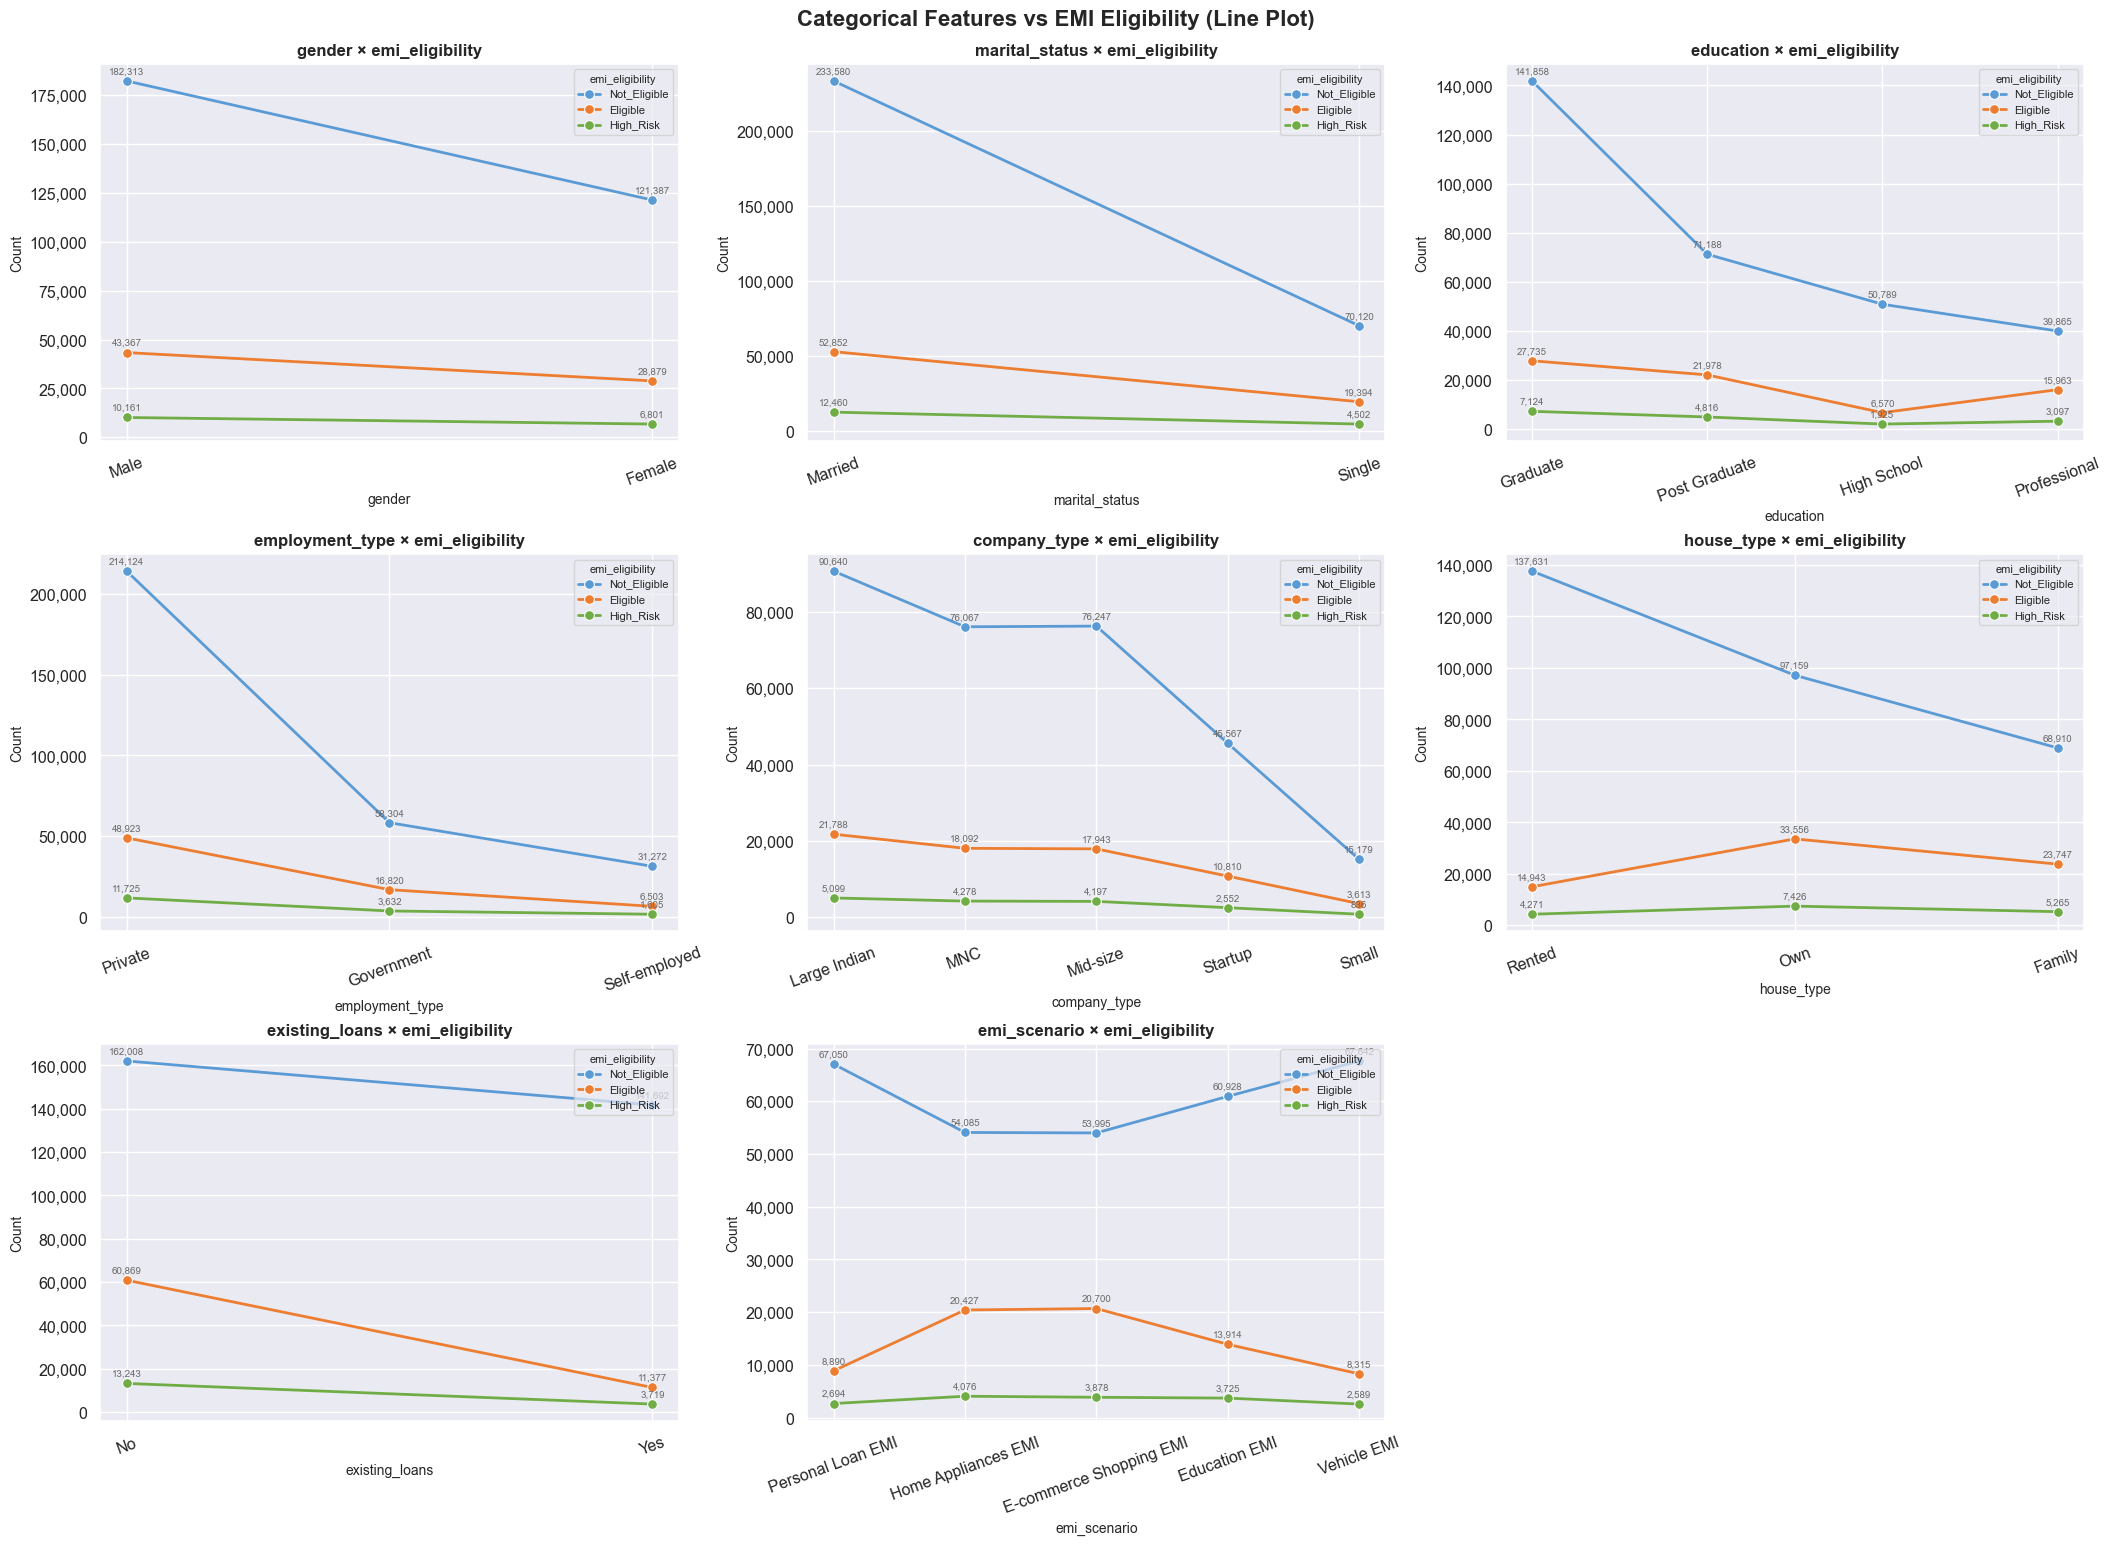

In [554]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Config ─────────────────────────────────────────────────────────────
CATEGORICAL_COLS = [
    "gender", "marital_status", "education", "employment_type",
    "company_type", "house_type", "existing_loans", "emi_scenario"
]
TARGET = "emi_eligibility"

PALETTE = {
    "Not_Eligible": "#5B9BD5",
    "Eligible": "#ED7D31",
    "High_Risk": "#70AD47"
}

N_COLS = 3
N_ROWS = -(-len(CATEGORICAL_COLS) // N_COLS)

sns.set_theme(style="darkgrid", font_scale=1.05)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(7 * N_COLS, 5 * N_ROWS),
    constrained_layout=True
)
axes = axes.flatten()

for ax, col in zip(axes, CATEGORICAL_COLS):
    order = df[col].value_counts().index.tolist()

    plot_df = (
        df.groupby([col, TARGET])
          .size()
          .reset_index(name="count")
    )
    plot_df[col] = pd.Categorical(plot_df[col], categories=order, ordered=True)
    plot_df = plot_df.sort_values(col)

    sns.lineplot(
        data=plot_df,
        x=col,
        y="count",
        hue=TARGET,
        hue_order=list(PALETTE.keys()),
        palette=PALETTE,
        marker="o",
        linewidth=2,
        markersize=7,
        estimator=None,
        sort=False,
        ax=ax
    )

    for _, row in plot_df.iterrows():
        ax.text(
            x=order.index(row[col]),
            y=row["count"] + plot_df["count"].max() * 0.015,
            s=f'{int(row["count"]):,}',
            ha="center",
            va="bottom",
            fontsize=7,
            color="dimgray"
        )

    ax.set_title(f"{col} × {TARGET}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    ax.legend(
        title=TARGET,
        title_fontsize=8,
        fontsize=8,
        loc="upper right",
        framealpha=0.7
    )

for ax in axes[len(CATEGORICAL_COLS):]:
    ax.set_visible(False)

plt.suptitle("Categorical Features vs EMI Eligibility (Line Plot)", fontsize=16, fontweight="bold", y=1.02)
plt.savefig("emi_eligibility_lineplots.png", dpi=150, bbox_inches="tight")
plt.show()


Interpretations:

1. Columns not required: gender, marital_status
2. label encoding: education, existing loans
3. one hot encoding: employment_type, company_type, house_type, emi_scenario

In [555]:
# feature vs target plot (numeric vs categorical)

numeric_cols = [
              'age',
              'monthly_salary',
              'years_of_employment',
              'monthly_rent',
              'family_size',
              'dependents',
              'debt_to_income',
              'expense_to_income',
              'total_expenses',
              'savings_ratio',
              'loan_to_income_ratio',
              'current_emi_amount',
              'credit_score',
              'bank_balance',
              'emergency_fund',
              'requested_amount_log',
              'requested_tenure'
]

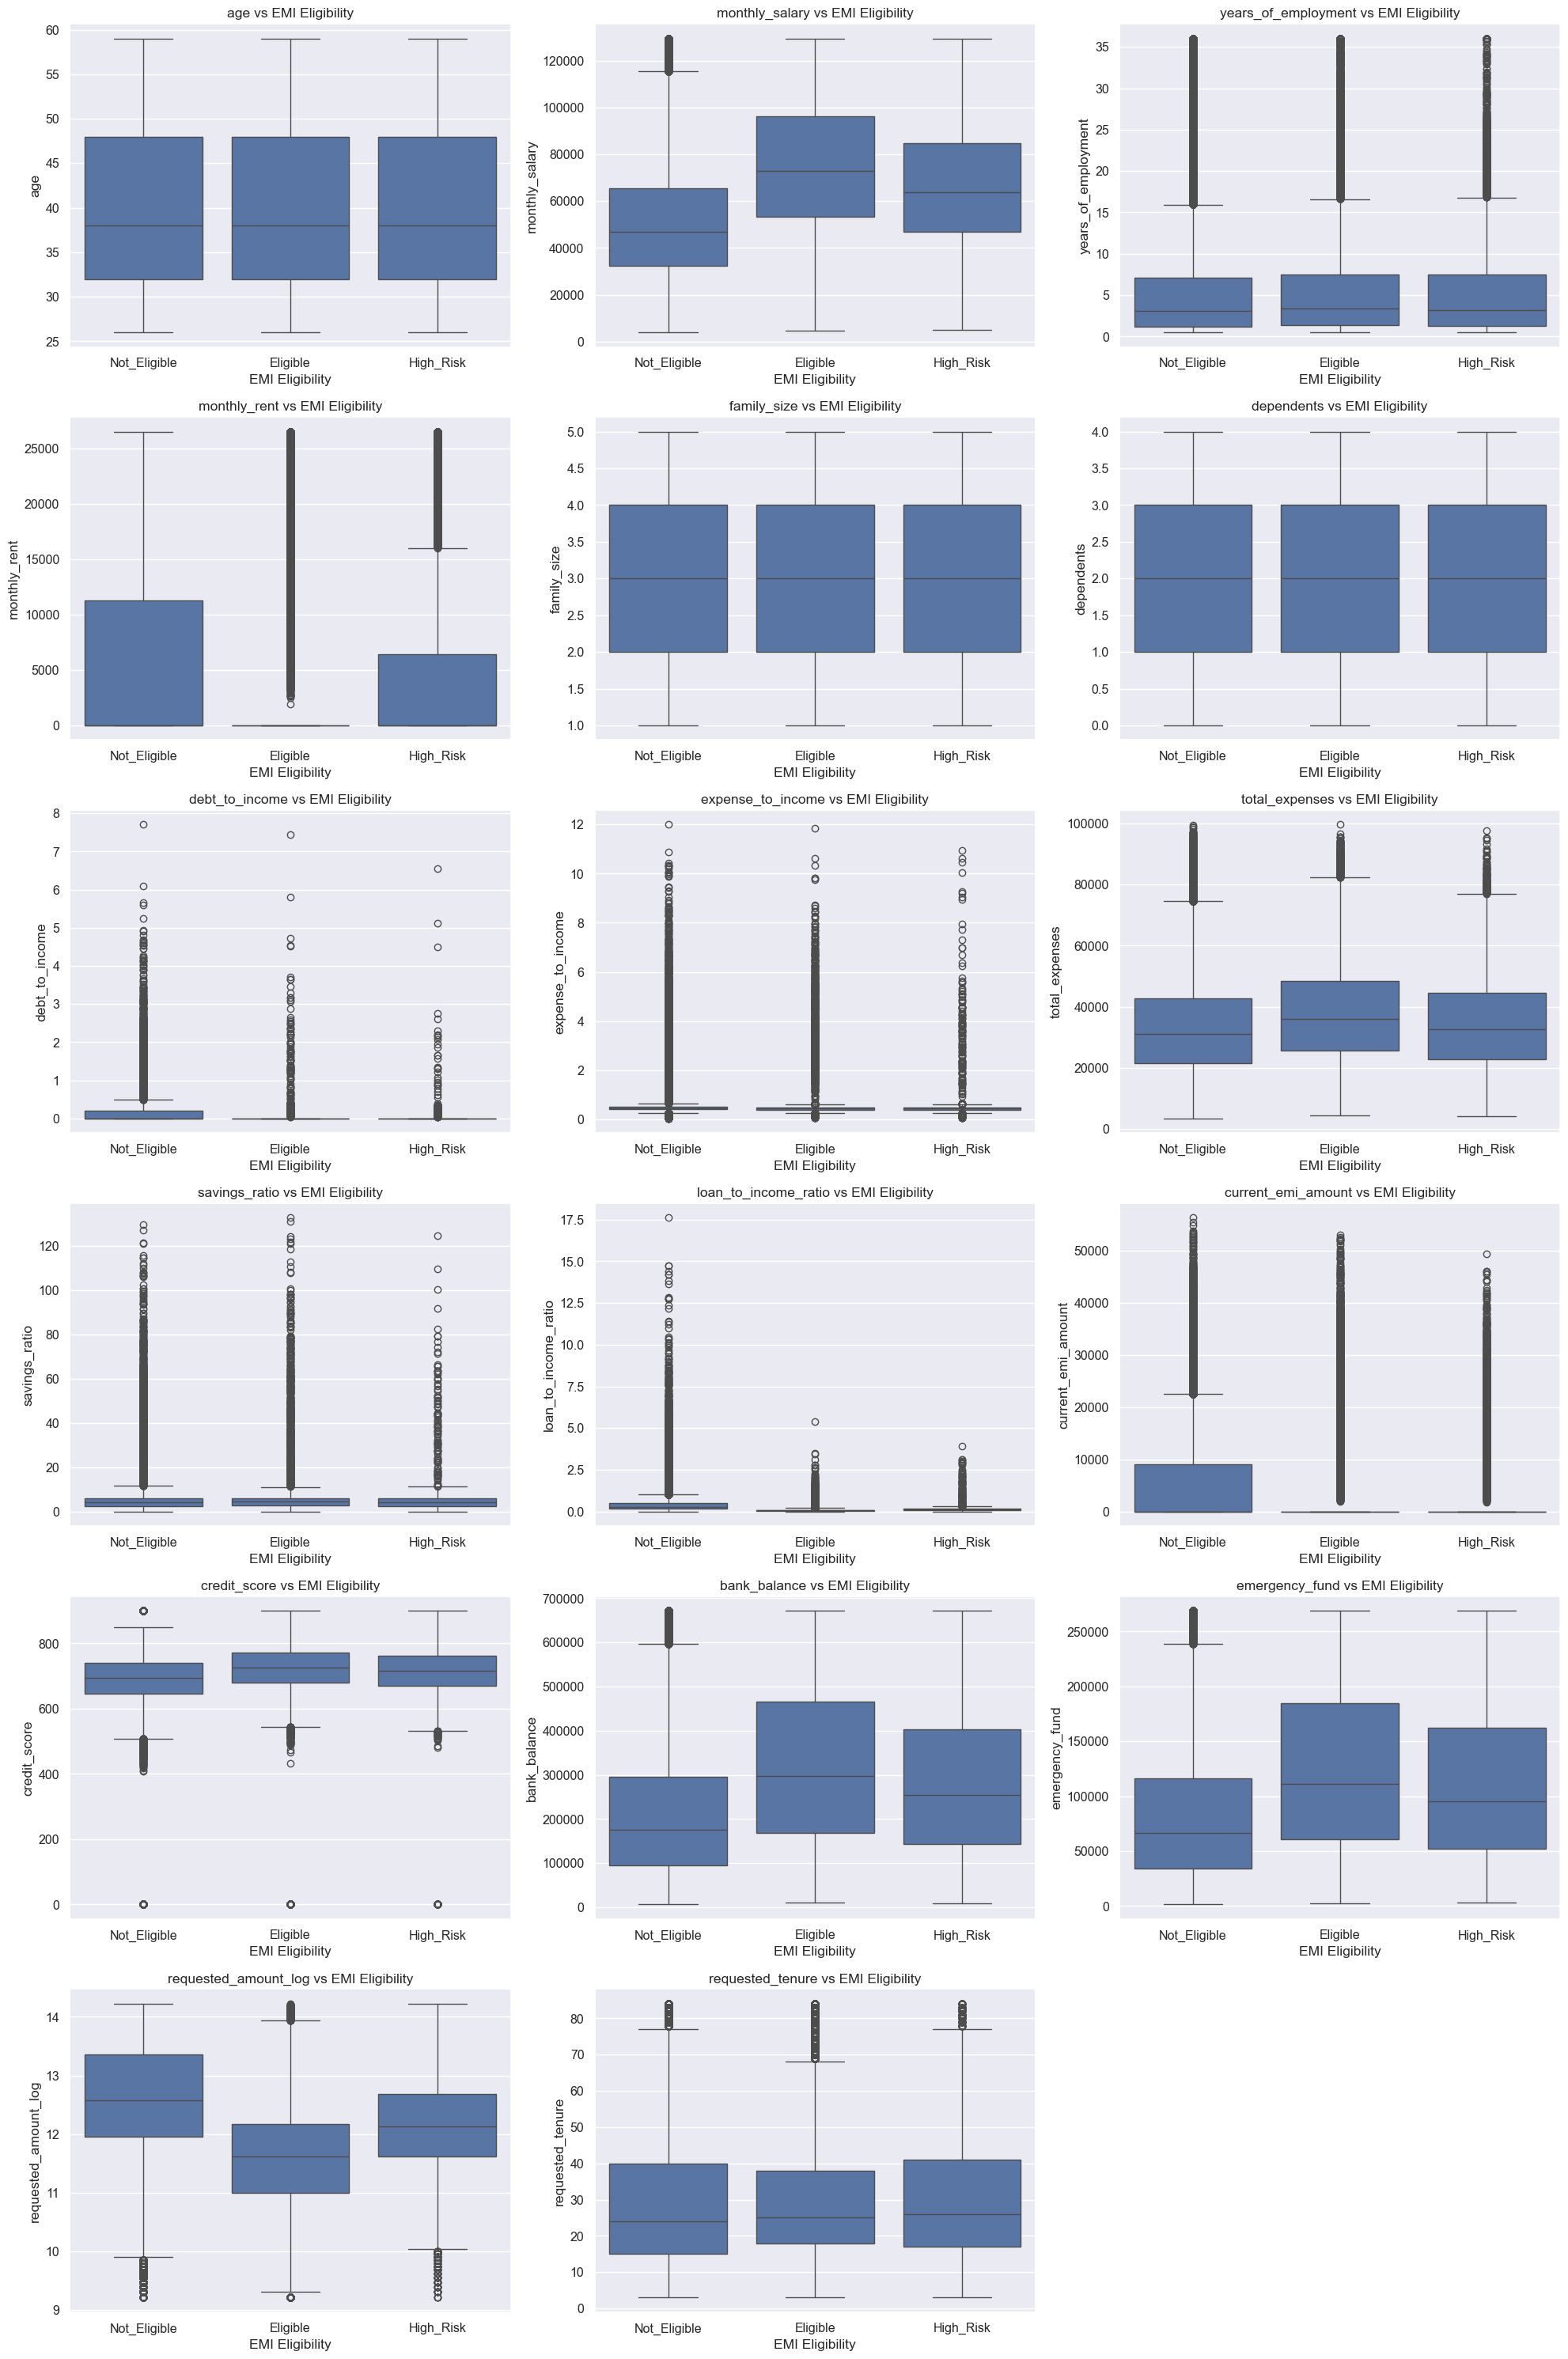

In [556]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(6, 3, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x='emi_eligibility',
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs EMI Eligibility")
    axes[i].set_xlabel("EMI Eligibility")
    axes[i].set_ylabel(col)

# Remove extra empty plots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. **Columns not required:** age, family_size, dependents

In [557]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'existing_loans',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'emi_scenario', 'requested_amount', 'requested_tenure',
       'emi_eligibility', 'max_monthly_emi', 'requested_amount_log',
       'debt_to_income', 'expense_to_income', 'total_expenses',
       'savings_ratio', 'loan_to_income_ratio'],
      dtype='object')

In [558]:
del df['gender']
del df['marital_status']
del df['age']
del df['family_size']
del df['dependents']

## Encoding the data

In [559]:
education_map = {
    'High School' : 0,
    'Graduate' : 1,
    'Post Graduate' : 2,
    'Professional' : 3
}

existing_loans_map = {
    'No' : 0,
    'Yes' : 1
}

emi_eligibility_map = {
    'Not_Eligible' : 0,
    'Eligible' : 1,
    'High_Risk' : 2
}
df['education'] = df['education'].map(education_map)
df['existing_loans'] = df['existing_loans'].map(existing_loans_map)
df['emi_eligibility'] = df['emi_eligibility'].map(emi_eligibility_map)

df = pd.get_dummies(
    df,
    columns=['employment_type', 'company_type', 'house_type', 'emi_scenario'],
    drop_first=True,
    dtype='int8'
)

In [560]:
# from sklearn.preprocessing import LabelEncoder

# label_encoder_dict = {}
# for col in df.columns:
#   if df[col].dtype == "object":
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     label_encoder_dict[col] = le


In [561]:
df.head()

,education,monthly_salary,years_of_employment,monthly_rent,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,...,company_type_MNC,company_type_Mid-size,company_type_Small,company_type_Startup,house_type_Own,house_type_Rented,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI
0,3,82600.0,0.9,20000.0,1,23700.0,660.0,303200.0,70200.0,850000.0,...,0,1,0,0,0,1,0,0,1,0
1,1,21500.0,7.0,0.0,1,4100.0,714.0,92500.0,26900.0,128000.0,...,1,0,0,0,0,0,0,0,0,0
2,3,86100.0,5.8,0.0,0,0.0,650.0,671650.0,268900.0,306000.0,...,0,0,0,1,1,0,1,0,0,0
3,0,66800.0,2.2,0.0,0,0.0,685.0,440900.0,178100.0,304000.0,...,0,1,0,0,1,0,0,0,0,1
4,3,57300.0,3.4,0.0,0,0.0,770.0,97300.0,28200.0,252000.0,...,0,1,0,0,0,0,0,1,0,0


In [562]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392908 entries, 0 to 404799
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   education                         392908 non-null  int64  
 1   monthly_salary                    392908 non-null  float64
 2   years_of_employment               392908 non-null  float64
 3   monthly_rent                      392908 non-null  float64
 4   existing_loans                    392908 non-null  int64  
 5   current_emi_amount                392908 non-null  float64
 6   credit_score                      392908 non-null  float64
 7   bank_balance                      392908 non-null  float64
 8   emergency_fund                    392908 non-null  float64
 9   requested_amount                  392908 non-null  float64
 10  requested_tenure                  392908 non-null  int64  
 11  emi_eligibility                   392908 non-null  int64 

## Splitting the data

In [563]:
X = df.drop(['emi_eligibility', 'max_monthly_emi'],axis=1)
y = df['emi_eligibility']

In [564]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=70)

In [565]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(314326, 29) (78582, 29) (314326,) (78582,)


In [566]:
X.isna().sum()

education                           0
monthly_salary                      0
years_of_employment                 0
monthly_rent                        0
existing_loans                      0
current_emi_amount                  0
credit_score                        0
bank_balance                        0
emergency_fund                      0
requested_amount                    0
requested_tenure                    0
requested_amount_log                0
debt_to_income                      0
expense_to_income                   0
total_expenses                      0
savings_ratio                       0
loan_to_income_ratio                0
employment_type_Private             0
employment_type_Self-employed       0
company_type_MNC                    0
company_type_Mid-size               0
company_type_Small                  0
company_type_Startup                0
house_type_Own                      0
house_type_Rented                   0
emi_scenario_Education EMI          0
emi_scenario

## Data balancing

In [567]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='not majority', random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [568]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({0: 243116, 1: 57728, 2: 13482})
After SMOTE: Counter({0: 243116, 1: 243116, 2: 243116})


## Logistic regression

In [569]:
from sklearn.linear_model import LogisticRegression #import

log_model = LogisticRegression(fit_intercept=True) #initialise
log_model.fit(X_train_smote, y_train_smote) #fit - all magic
print(log_model.predict(X_test))     #predict
print(y_test)

[2 0 0 ... 2 0 0]
232913    1
298967    0
122808    0
266145    1
34500     1
         ..
393717    0
378150    0
233397    0
339847    0
25718     0
Name: emi_eligibility, Length: 78582, dtype: int64


c:\Users\nived\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7740576722404622
Precision: 0.8971837860745121
Recall: 0.7740576722404622
F1 Score: 0.822651312837344
ROC AUC Score: 0.9332271291032952

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     60584
           1       0.74      0.73      0.74     14518
           2       0.13      0.54      0.21      3480

    accuracy                           0.77     78582
   macro avg       0.62      0.69      0.61     78582
weighted avg       0.90      0.77      0.82     78582


Confusion Matrix:
 [[48264  2657  9663]
 [  544 10668  3306]
 [  479  1106  1895]]


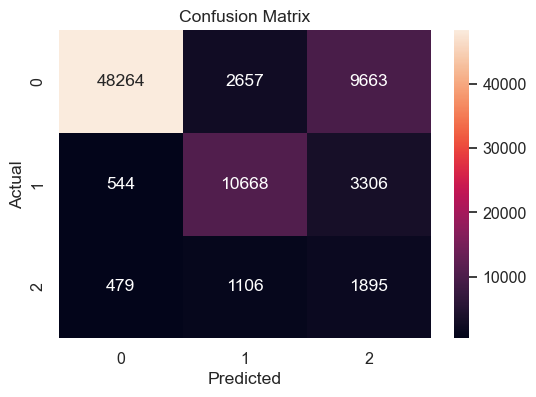

In [570]:
# Classification Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = log_model.predict(X_test)

# Probabilities for ROC-AUC
# For multiclass ROC AUC, we need probabilities for all classes
y_prob = log_model.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
# Specify average='weighted' for multiclass classification
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
# Specify multi_class and average for multiclass ROC AUC
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Random forest classifier

In [571]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [572]:


# max_depth=[2,4,8,10,11,12,13,15,18,20]
# cross_val_rf=[]

# for d in max_depth:
#   rf_classifier=RandomForestClassifier(max_depth=d, random_state=0)
#   rf_classifier.fit(X_train,y_train)
#   print("Depth : ", d, "cross_val_score : ", cross_val_score(rf_classifier,X_train_smote,y_train_smote,cv = 5).mean())
#   cross_val_rf.append(cross_val_score(rf_classifier,X_train_smote,y_train_smote,cv = 5).mean())

In [573]:
rf_classifier=RandomForestClassifier(max_depth=12, random_state=0)
rf_classifier.fit(X_train_smote,y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Accuracy: 0.8523071441296989
Precision: 0.9065769538853097
Recall: 0.8523071441296989
F1 Score: 0.8743995783213091
ROC AUC Score: 0.9689683249460626

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.88      0.93     60584
           1       0.78      0.79      0.79     14518
           2       0.21      0.54      0.30      3480

    accuracy                           0.85     78582
   macro avg       0.66      0.74      0.67     78582
weighted avg       0.91      0.85      0.87     78582


Confusion Matrix:
 [[53557  2410  4617]
 [  511 11525  2482]
 [  783   803  1894]]


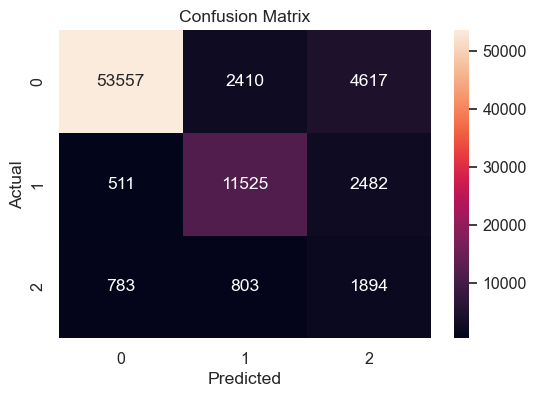

In [574]:
# Classification Evaluation Metrics

# Predictions
y_pred = rf_classifier.predict(X_test)

# Probabilities for ROC-AUC
# For multiclass ROC AUC, we need probabilities for all classes
y_prob = rf_classifier.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
# Specify average='weighted' for multiclass classification
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
# Specify multi_class and average for multiclass ROC AUC
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## XGBoost classifier

In [575]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [576]:

# max_depth=[2,3,4,5,6,7,8]
# cross_val_xgb=[]

# for d in max_depth:
#   xgb_classifier=XGBClassifier(max_depth=d, random_state=0)
#   xgb_classifier.fit(X_train_smote,y_train_smote)
#   print("Depth : ", d, "cross_val_score : ", cross_val_score(xgb_classifier,X_train_smote,y_train_smote,cv = 5).mean())
#   cross_val_xgb.append(cross_val_score(xgb_classifier,X_train_smote,y_train_smote,cv = 5).mean())

In [577]:
xgb_classifier = XGBClassifier(max_depth=7, random_state=42)

xgb_classifier.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Accuracy: 0.9503321371306406
Precision: 0.9563556608855099
Recall: 0.9503321371306406
F1 Score: 0.9529007020986655
ROC AUC Score: 0.9947992856098704

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     60584
           1       0.95      0.92      0.94     14518
           2       0.49      0.64      0.56      3480

    accuracy                           0.95     78582
   macro avg       0.81      0.85      0.82     78582
weighted avg       0.96      0.95      0.95     78582


Confusion Matrix:
 [[59038   179  1367]
 [  196 13428   894]
 [  757   510  2213]]


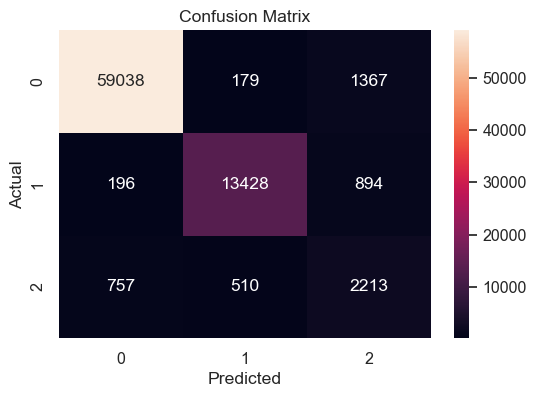

In [578]:
# Classification Evaluation Metrics

# Predictions
y_pred = xgb_classifier.predict(X_test)

# Probabilities for ROC-AUC
# For multiclass ROC AUC, we need probabilities for all classes
y_prob = xgb_classifier.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
# Specify average='weighted' for multiclass classification
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
# Specify multi_class and average for multiclass ROC AUC
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## MLFlow (classification)

In [579]:
import mlflow
import mlflow.sklearn

In [580]:
with mlflow.start_run(run_name="XGBoost_Classifier"):

    model = xgb_classifier
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # log parameters
    mlflow.log_param("model", "XGBoost Classifier")

    # log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # log model
    mlflow.sklearn.log_model(model, "model")

Exception: Run with UUID ad8110e885ee456097f0d13ff0b95e9d is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True

In [ ]:
mlflow.log_param("max_depth", model.max_depth)

7

## Comparison table (classification)

In [581]:
# Classification

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_classifier,
    "XGBoost": xgb_classifier
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [582]:
comparison_table_cl = pd.DataFrame(results)
comparison_table_cl

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.774058,0.897184,0.774058,0.822651
1,Random Forest,0.852307,0.906577,0.852307,0.874400
2,XGBoost,0.950332,0.956356,0.950332,0.952901


## Model selection

In [583]:
best_model = xgb_classifier

feature_columns = X_train.columns


importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(f"Feature Importances for {model.__class__.__name__}:")
print(feature_importance)
print("-" * 30) # Separator

Feature Importances for XGBClassifier:
                             Feature  Importance
4                     existing_loans    0.143462
16              loan_to_income_ratio    0.098703
24                 house_type_Rented    0.080695
21                company_type_Small    0.065541
18     employment_type_Self-employed    0.059121
22              company_type_Startup    0.052713
26  emi_scenario_Home Appliances EMI    0.051500
20             company_type_Mid-size    0.051448
28          emi_scenario_Vehicle EMI    0.051241
27    emi_scenario_Personal Loan EMI    0.044394
19                  company_type_MNC    0.040243
25        emi_scenario_Education EMI    0.039638
12                    debt_to_income    0.034363
3                       monthly_rent    0.023291
17           employment_type_Private    0.020498
5                 current_emi_amount    0.019679
1                     monthly_salary    0.016439
23                    house_type_Own    0.015975
14                    total_ex

In [604]:
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# -----------------------------
# SELECTED FEATURES
# -----------------------------

classifier_features = ['monthly_salary',
'bank_balance', 
'emergency_fund',
'savings_ratio',
'existing_loans',
'current_emi_amount',
'debt_to_income',
'loan_to_income_ratio',
'expense_to_income',
'requested_amount',
'requested_tenure',
'years_of_employment',
'monthly_rent',
'total_expenses',
'credit_score']

# -----------------------------
# PICK FEATURES FROM SMOTE DATA
# -----------------------------

X_train_selected = X_train_smote[classifier_features]
X_test_selected = X_test[classifier_features]

# -----------------------------
# TRAIN MODEL
# -----------------------------

classifier = XGBClassifier(max_depth=15, random_state=42)

classifier.fit(X_train_selected, y_train_smote)

# -----------------------------
# PREDICTIONS
# -----------------------------

pred_class = classifier.predict(X_test_selected)

accuracy = accuracy_score(y_test, pred_class)

print("Classifier Accuracy:", accuracy)

# -----------------------------
# SAVE MODEL
# -----------------------------

joblib.dump(classifier, "models/emi_classifier.pkl")

print("Model saved successfully")

Classifier Accuracy: 0.9464381155989922
Model saved successfully


In [603]:
classifier_features

['monthly_salary',
 'bank_balance',
 'emergency_fund',
 'savings_ratio',
 'existing_loans',
 'current_emi_amount',
 'debt_to_income',
 'loan_to_income_ratio',
 'expense_to_income',
 'requested_amount',
 'requested_tenure',
 'years_of_employment',
 'monthly_rent',
 'total_expenses',
 'credit_score']

In [600]:
X_train_smote.columns

Index(['education', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance',
       'emergency_fund', 'requested_amount', 'requested_tenure',
       'requested_amount_log', 'debt_to_income', 'expense_to_income',
       'total_expenses', 'savings_ratio', 'loan_to_income_ratio',
       'employment_type_Private', 'employment_type_Self-employed',
       'company_type_MNC', 'company_type_Mid-size', 'company_type_Small',
       'company_type_Startup', 'house_type_Own', 'house_type_Rented',
       'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI',
       'emi_scenario_Personal Loan EMI', 'emi_scenario_Vehicle EMI'],
      dtype='object')